<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/SpinStar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

General Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import comb

In [2]:
!rm -rf Qaos
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Qaos.git

# Move into the repo
%cd Qaos

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from gqs.states import Initial_state
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance
from gqs.dynamics import Hamiltonian_QK, floquet_operator_from_H
from gqs.PlotsDynamics import plot_two_gqs_trajectory_row
from gqs.Gamma import Compare_distances_All, Gamma_calculator
from gqs.SSCI import SSCI_calculator, gqs_coverage_from_global_states, plot_gqs_mass_mollweide

Functions for constructing the Hamiltonian:  $H = \frac{\omega}{2}\sigma_S^x + \Omega \, \sigma_S^z \otimes \frac{1}{N}\sum_{k=1}^{N}\,\sigma_k^z$

In [4]:
# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)


# ---------------------------------------------------------------------------
# Hamiltonian construction
# ---------------------------------------------------------------------------

def _single_site_op(op, k, N):
    """Embed single-qubit operator on site k (0-indexed) in an N-qubit space."""
    factors = [op if j == k else I2 for j in range(N)]
    result = factors[0]
    for f in factors[1:]:
        result = np.kron(result, f)
    return result


def build_hamiltonian(N, omega, gamma, Omega):
    """
    H = (omega/2) sigma_s^x ⊗ I_E
      + (gamma/2N) I_s ⊗ sum_k sigma_k^x
      + (Omega/N) sigma_s^z ⊗ sum_k sigma_k^z

    The interaction term is diagonal in the computational basis of E,
    making it natural to project onto that basis.

    Args:
        N:     number of environment qubits
        omega: system transverse field strength
        gamma: environment transverse field strength
        Omega: system-environment coupling strength

    Returns:
        H: (2^(N+1), 2^(N+1)) complex Hamiltonian matrix
    """
    dim_E = 2**N
    I_E = np.eye(dim_E, dtype=complex)

    # System transverse field
    H_sys = (omega / 2) * np.kron(sigma_x, I_E)

    # System-environment interaction (diagonal in computational basis of E)
    sum_z_E = sum(_single_site_op(sigma_z, k, N) for k in range(N))
    H_int = (Omega / N) * np.kron(sigma_z, sum_z_E)

    return H_sys + H_int

Function for computing the projected ensemble.

In [5]:
def compute_projected_ensemble(psi, N):
    """
    Project the joint state onto the computational basis of the environment.

    For each outcome m in {0,...,2^N-1} the (unnormalized) system state is
        |phi_m> = <m|_E |psi>,
    with probability p_m = ||phi_m||^2.

    The normalized state is parameterized as
        |phi_m> = sqrt(p) |0> + sqrt(1-p) e^{i phi} |1>
    (global phase removed by making the |0> coefficient real and non-negative).

    Args:
        psi: (2^(N+1),) joint state vector
        N:   number of environment qubits

    Returns:
        probs   : (M,) measurement probabilities p_m  (M <= 2^N)
        p_vals  : (M,) qubit population  p = |<0|phi_m>|^2
        phi_vals: (M,) relative phase    phi in [-pi, pi]
    """
    psi_mat = psi.reshape(2, 2**N)  # row = system index, col = env outcome m

    probs, p_vals, phi_vals = [], [], []
    for m in range(2**N):
        unnorm = psi_mat[:, m]
        prob = float(np.real(unnorm.conj() @ unnorm))
        if prob < 1e-12:
            continue

        phi_m = unnorm / np.sqrt(prob)
        alpha, beta = phi_m[0], phi_m[1]

        # Fix global phase: rotate so alpha is real and non-negative
        if abs(alpha) > 1e-12:
            phase = np.angle(alpha)
            alpha = alpha * np.exp(-1j * phase)
            beta  = beta  * np.exp(-1j * phase)

        p   = float(np.real(alpha.conj() * alpha))
        phi = float(np.angle(beta)) % (2 * np.pi)

        probs.append(prob)
        p_vals.append(p)
        phi_vals.append(phi)

    return np.array(probs), np.array(p_vals), np.array(phi_vals)

Construct Initial State as $|\Psi_{SE}^0\rangle = |0\rangle \otimes \left( \cos\frac{\theta}{2}|0\rangle + \sin\frac{\theta}{2}|1\rangle \right)^{\otimes N} $
where $\theta = \arccos(m_0) $ with $m_0 = \langle\sigma_z\rangle$ being the net magnetization of the environment.

In [6]:
def make_initial_state(N, m0):
    theta = np.arccos(m0)
    psi_e = np.array([np.cos(theta / 2), np.sin(theta / 2)], dtype=complex)
    psi_s = np.array([1, 0], dtype=complex)

    psi_E = psi_e
    for _ in range(N - 1):
        psi_E = np.kron(psi_E, psi_e)
    return np.kron(psi_s, psi_E)

Example evolution of the system using `build_hamiltonian` and `make_initial_state`.

In [7]:
def evolve_spin_star(H, psi0, N, times):
    E, V = np.linalg.eigh(H)
    c0 = V.conj().T @ psi0

    probs_all = []
    p_vals_all = []
    phi_vals_all = []
    psi_global_t = []

    for t in times:
        psi_t = V @ (np.exp(-1j * E * t) * c0)

        probs, p_vals, phi_vals = compute_projected_ensemble(
            psi_t, N
        )

        probs_all.append(probs)
        p_vals_all.append(p_vals)
        phi_vals_all.append(phi_vals)
        psi_global_t.append(psi_t)

    return probs_all, p_vals_all, phi_vals_all, psi_global_t

In [13]:
# MODEL_PARAMS
N = 8
omega = 1.0
Omega = 0.5
m0 = 0.5 # Spin coherent environment state, takes value between, 0 and 1
t0 = 0.0
t1 = 1.0
n_timesteps = 1001

# RUN MODEL DYNAMICS
H = build_hamiltonian(N, omega, gamma=0.0, Omega=Omega)
psi0 = make_initial_state(N, m0)

times = np.linspace(t0, t1, n_timesteps, endpoint=False)

probs_t, p_vals_t, phi_vals_t, psi_global_t = evolve_spin_star(H, psi0, N, times)

In [9]:

psi_global_t = np.asarray(psi_global_t)

print(times.shape)          # (1001,)
print(psi_global_t.shape)   # first dimension must be 1001

(1001,)
(1001, 512)


Outputs three arrays. Assuming ensemble is written as collections of $(q, p, \phi)$, each entry in `probs_t`, `p_vals_t`, and `phi_vals_t` corresponds to the collected $q$, $p$, $\phi$ values per timestep.

Quick check that this produces the proper time-averaged plot

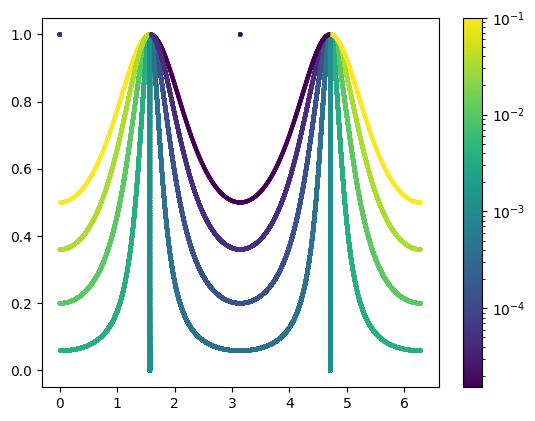

In [10]:
probs_tavg = np.concatenate(probs_t)
p_vals_tavg = np.concatenate(p_vals_t)
phi_vals_tavg = np.concatenate(phi_vals_t)

plt.figure()
plt.scatter(phi_vals_tavg, p_vals_tavg, s=4, c=probs_tavg, norm=LogNorm())
plt.colorbar()

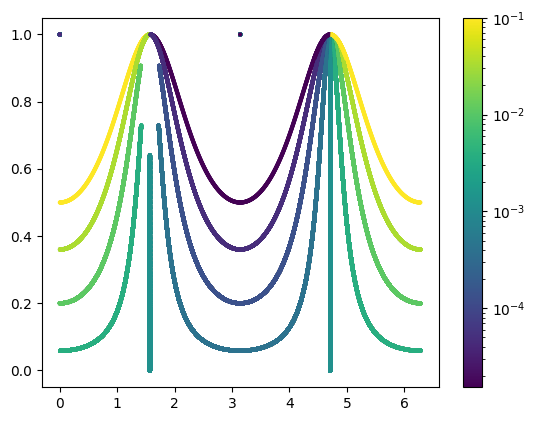

In [12]:
probs_tavg = np.concatenate(probs_t)
p_vals_tavg = np.concatenate(p_vals_t)
phi_vals_tavg = np.concatenate(phi_vals_t)

plt.figure()
plt.scatter(phi_vals_tavg, p_vals_tavg, s=4, c=probs_tavg, norm=LogNorm())
plt.colorbar()

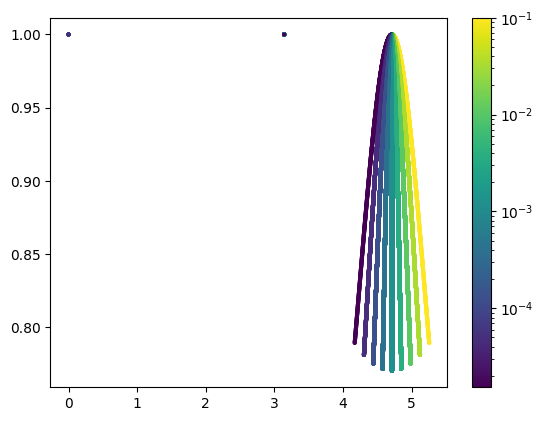

In [15]:
probs_tavg = np.concatenate(probs_t)
p_vals_tavg = np.concatenate(p_vals_t)
phi_vals_tavg = np.concatenate(phi_vals_t)

plt.figure()
plt.scatter(phi_vals_tavg, p_vals_tavg, s=4, c=probs_tavg, norm=LogNorm())
plt.colorbar()

In [29]:
result = gqs_coverage_from_global_states(
    psi_global_t,
    times=times,
    timesteps=100,
    site=0,
)

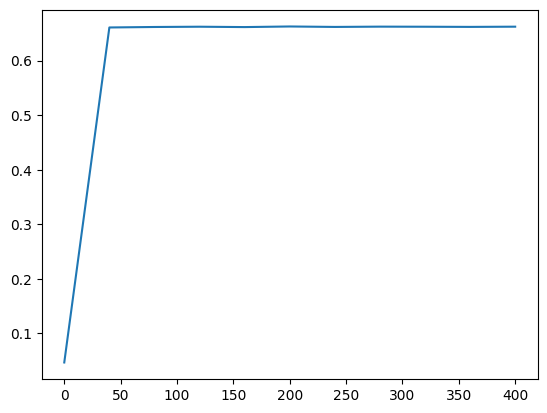

In [30]:
physical_times = result["times"]
coverage = result["coverage_index"]
nu_steps = result["aggregate_measure"]

plt.plot(physical_times, coverage)

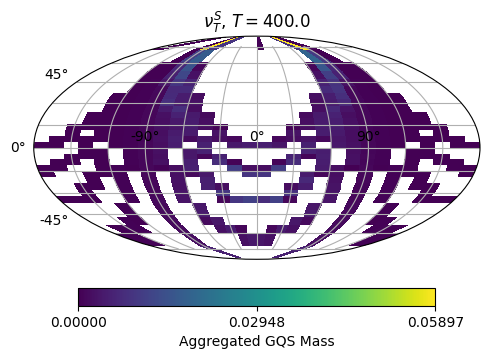

In [31]:
nu_steps = result["aggregate_measure"]
times_selected = result["times"]

plot_gqs_mass_mollweide(
    mass=nu_steps,
    theta_edges=result["theta_edges"],
    phi_edges=result["phi_edges"],
    traj_index=-1,
    title=rf"$\nu_T^S$, $T={times_selected[-1]:.1f}$",
)

In [37]:
times[0:10]

array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6])

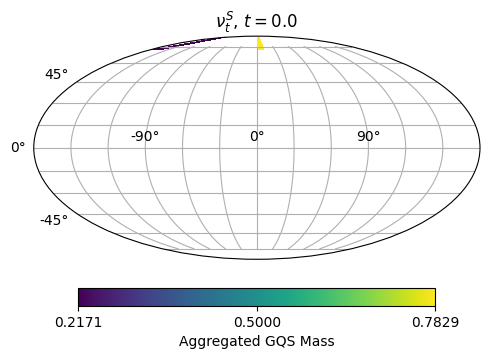

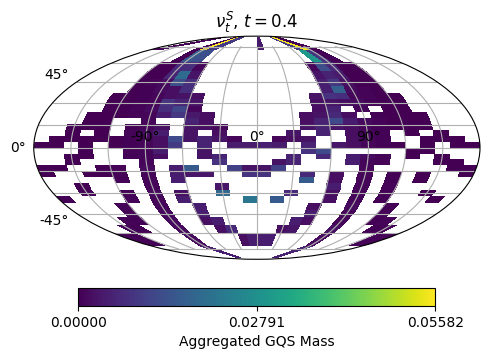

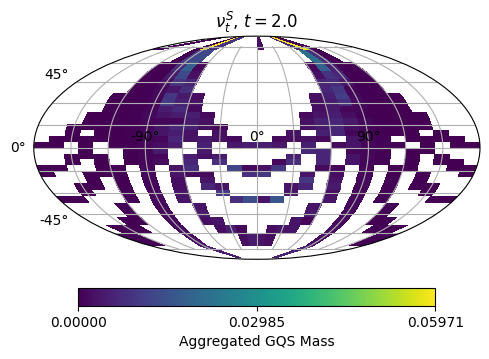

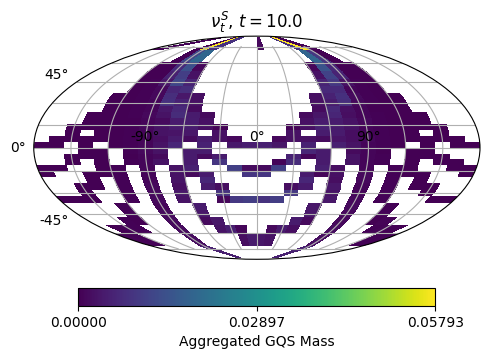

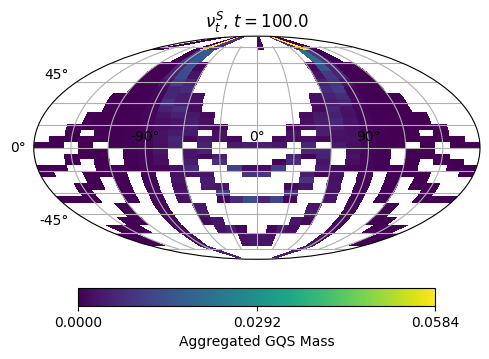

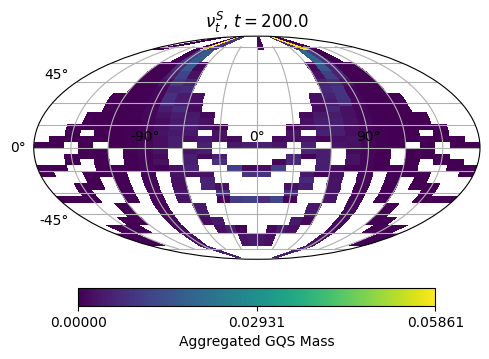

In [38]:
times_selected = [0,0.4,2,10,100,200]
for index in range(len(times_selected)):
    plot_gqs_mass_mollweide(
        mass=nu_steps,
        theta_edges=result["theta_edges"],
        phi_edges=result["phi_edges"],
        traj_index=index,
        title=rf"$\nu_t^S$, $t={times_selected[index]:.1f}$",
    )

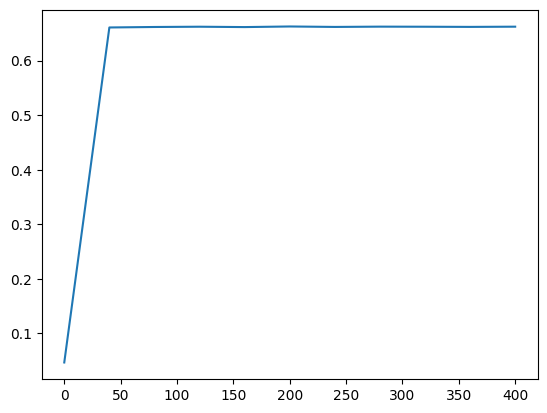

In [18]:
physical_times = result["times"]
coverage = result["coverage_index"]
nu_steps = result["aggregate_measure"]

plt.plot(physical_times, coverage)

In [45]:
def compute_projected_ensemble_theta_phi(psi, N, tol=1e-12):
    """
    Project the joint state onto the computational basis of the environment
    and return the Bloch-sphere coordinates of each conditional system state.

    Parameters
    ----------
    psi : ndarray, shape (2**(N+1),)
        Joint pure state of one system qubit and N environment qubits.
    N : int
        Number of environment qubits.
    tol : float
        Outcomes with probability below this value are discarded.

    Returns
    -------
    probs : ndarray, shape (M,)
        Probabilities of the retained environment outcomes.
    theta_vals : ndarray, shape (M,)
        Polar angles theta in [0, pi].
    phi_vals : ndarray, shape (M,)
        Azimuthal angles phi in [0, 2*pi).
    """
    psi = np.asarray(psi, dtype=complex)

    expected_dimension = 2 ** (N + 1)
    if psi.ndim != 1 or len(psi) != expected_dimension:
        raise ValueError(
            f"psi must have shape ({expected_dimension},); "
            f"received {psi.shape}."
        )

    # Rows: system states |0>, |1>
    # Columns: environment computational-basis outcomes
    psi_mat = psi.reshape(2, 2**N)

    # Probability of each environment outcome
    probs_all = np.sum(np.abs(psi_mat) ** 2, axis=0)

    # Remove outcomes with negligible probability
    keep = probs_all > tol
    probs = probs_all[keep]

    # Normalize each conditional system state
    conditional_states = (
        psi_mat[:, keep] / np.sqrt(probs)[None, :]
    )

    alpha = conditional_states[0]
    beta = conditional_states[1]

    # Bloch polar coordinate
    theta_vals = 2.0 * np.arctan2(
        np.abs(beta),
        np.abs(alpha),
    )

    # Relative phase; global phase cancels automatically
    phi_vals = np.zeros_like(theta_vals)

    away_from_poles = (
        (np.abs(alpha) > tol)
        & (np.abs(beta) > tol)
    )

    phi_vals[away_from_poles] = np.mod(
        np.angle(beta[away_from_poles])
        - np.angle(alpha[away_from_poles]),
        2.0 * np.pi,
    )

    # Phi is physically undefined at the north and south poles.
    # We assign phi=0 there.
    return probs, theta_vals, phi_vals

In [47]:
def evolve_spin_star_t(H, psi0, N, times):
    E, V = np.linalg.eigh(H)
    c0 = V.conj().T @ psi0

    probs_all = []
    theta_vals_all = []
    phi_vals_all = []
    psi_global_t = []

    for t in times:
        psi_t = V @ (np.exp(-1j * E * t) * c0)

        probs, p_vals, phi_vals = compute_projected_ensemble_theta_phi(
            psi_t, N
        )

        probs_all.append(probs)
        theta_vals_all.append(p_vals)
        phi_vals_all.append(phi_vals)
        psi_global_t.append(psi_t)

    return probs_all, theta_vals_all, phi_vals_all, psi_global_t

In [48]:
# MODEL_PARAMS
N = 8
omega = 1.0
Omega = 0.5
m0 = 0.5 # Spin coherent environment state, takes value between, 0 and 1
t0 = 0.0
t1 = 10.0
n_timesteps = 1001

# RUN MODEL DYNAMICS
H = build_hamiltonian(N, omega, gamma=0.0, Omega=Omega)
psi0 = make_initial_state(N, m0)

times = np.linspace(t0, t1, n_timesteps, endpoint=False)

probs_t, theta_vals_t, phi_vals_t, psi_global_t = evolve_spin_star_t(H, psi0, N, times)

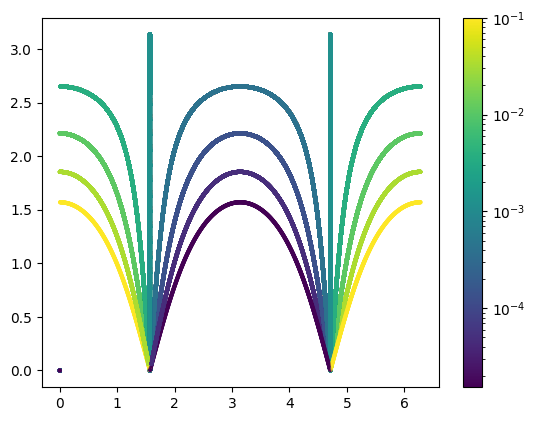

In [50]:
probs_tavg = np.concatenate(probs_t)
theta_vals_tavg = np.concatenate(theta_vals_t)
phi_vals_tavg = np.concatenate(phi_vals_t)

plt.figure()
plt.scatter(phi_vals_tavg, theta_vals_tavg, s=4, c=probs_tavg, norm=LogNorm())
plt.colorbar()